# PGA Perceptron Model + XGBoost Benchmark + Hyperparameter Tuning

Predict Peak Ground Acceleration (PGA) from earthquake features.

**Target**: `PGA` (log-transformed — distribution is heavily right-skewed, spans 0.3–128)

Four models trained on the **same 50/50 train/val split**, with the training half oversampled 100× via bootstrap + Gaussian noise jitter:
- **v1 (baseline MLP)** — original `Norm_*` features as-is.
- **v2 (improved MLP)** — GMPE-style feature engineering, standardized inputs, regularized network, Huber loss.
- **xgb (XGBoost, default-ish)** — gradient boosting on v2 features.
- **xgb_tuned (XGBoost + Optuna)** — same model, hyperparameters chosen by Bayesian optimization (TPE) over 5-fold CV (CV runs on the original, non-oversampled train half to avoid leak).

Data: `pga_data/SMDataCaragaCleanNormalized.xlsx`

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__, '  XGBoost:', xgb.__version__, '  Optuna:', optuna.__version__)

TensorFlow: 2.19.0   XGBoost: 3.2.0   Optuna: 4.8.0


## 1. Load and inspect data

In [2]:
DATA_PATH = '../pga_data/SMDataCaragaCleanNormalized.xlsx'
df = pd.read_excel(DATA_PATH)
df['Station'] = df['Station'].str.strip()
print('Shape:', df.shape)
print('Stations:', df['Station'].value_counts().to_dict())
df.head()

Shape: (1095, 20)
Stations: {'MMCS': 448, 'SCPA': 433, 'SFSN': 131, 'AGBC': 83}


,Filename,Station,Date,Time,Depth_km,Station_Lat,Station_Long,EQ_Lat,EQ_Long,Epicentral_Distance,Hypocentral_Distance,Mw_Homogenized,PGA,Joyner_Boore_Distance_RJB,Rupture_Distance,Norm_Mw,Norm_Depth,Norm_RJB,Norm_Epidist,Norm_Hypodist
0,2019_0115_2004_MMCS.EVT,MMCS,NaN,20:04:06,80,9.760241,125.463063,5.60,127.10,496.508539,502.912248,5.800,1.3,505.573722,511.864033,0.612027,0.148148,0.871399,0.831179,0.829564
1,2019_0115_2004_SCPA.EVT,SCPA,2019-01-15 00:00:00,20:04:38,80,9.782181,125.489397,5.60,127.10,497.738871,504.126952,5.800,1.0,506.813216,513.088332,0.612027,0.148148,0.873537,0.833240,0.831596
2,2019_0123_0947_MMCS.EVT,MMCS,2019-01-23 00:00:00,09:47:22,7,9.760241,125.463063,9.74,126.44,107.084965,107.313511,4.884,2.2,105.126808,105.359602,0.389913,0.012963,0.180687,0.178823,0.167775
3,2019_0123_0947_SCPA.EVT,SCPA,2019-01-23 00:00:00,09:47:27,7,9.782181,125.489397,9.74,126.44,104.277507,104.512193,4.884,1.4,102.250711,102.490038,0.389913,0.012963,0.175726,0.174120,0.163089
4,2019_0123_1053_MMCS.EVT,MMCS,2019-01-23 00:00:00,10:53:29,8,9.760241,125.463063,9.75,126.47,110.353191,110.642789,4.951,0.8,108.544958,108.839367,0.406159,0.014815,0.186583,0.184298,0.173344


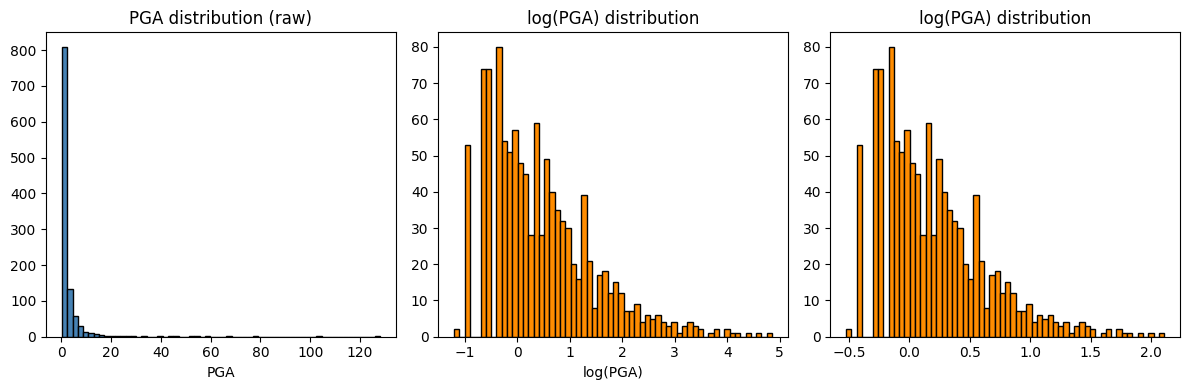

In [ ]:
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
pga_base_10 = np.log10(df['PGA'])
axes[0].hist(df['PGA'], bins=60, color='steelblue', edgecolor='k')
axes[0].set_title('PGA distribution (raw)'); axes[0].set_xlabel('PGA')
axes[1].hist(np.log(df['PGA']), bins=60, color='darkorange', edgecolor='k')
axes[1].set_title('log(PGA) distribution'); axes[1].set_xlabel('log(PGA)')
# axes[2].hist(np.log10(df['PGA']), bins=60, color='darkorange', edgecolor='k')
# axes[2].set_title('log(PGA) distribution'); axes[1].set_xlabel('log(PGA)')

sns.histplot(np.log10(df['PGA']))
plt.tight_layout(); plt.show()

## 2. Train/Val split (shared by all models)

50/50 split. The training half will be heavily oversampled (next section); the validation half is left untouched and serves both early-stopping and final evaluation. **Caveat:** with no separate held-out test set, the metrics in section 7+ are reported on the same val data the early-stopping callback peeks at, so reported R²/RMSE will be mildly optimistic. If you want honest test numbers later, switch to a 40/40/20 split.

In [4]:
y_raw = df['PGA'].values.astype(np.float32)
y = np.log(y_raw)
idx = np.arange(len(df))

idx_train, idx_val = train_test_split(idx, test_size=0.50, random_state=SEED)

y_train, y_val = y[idx_train], y[idx_val]
y_raw_train, y_raw_val = y_raw[idx_train], y_raw[idx_val]
print(f'Train: {len(idx_train)}, Val: {len(idx_val)}')

Train: 547, Val: 548


## 2a. Oversampling — bootstrap + Gaussian noise jitter

Inflate the **training half only** by sampling rows with replacement and adding small Gaussian noise (≈2% of each feature's std) to every continuous feature. Validation is left untouched.

- `OS_FACTOR` controls the oversampling ratio (default 100×: ~547 → ~54,700 rows).
- Bootstrap row indices `boot_idx` are generated **once** so all four models train on the same oversampled rows.
- Noise is applied per-feature in the next sections, with separate RNGs so each model sees a slightly different jitter realization (the bootstrap rows themselves are shared).
- Station dummies in v2 are **excluded** from jitter (a one-hot ±0.02 noise still keeps the encoding readable, but it's cleaner to skip).

In [5]:
OS_FACTOR = 100        # 100x oversampling: ~547 train rows -> ~54,700 rows
NOISE_FRAC_X = 0.02    # feature noise std as fraction of each feature's std

def jitter(X_sample, X_ref, noise_frac, rng, jitter_mask=None):
    """Add Gaussian noise to selected columns of X_sample, scaled by std of X_ref."""
    n, d = X_sample.shape
    if jitter_mask is None:
        jitter_mask = np.ones(d, dtype=bool)
    X_out = X_sample.astype(np.float32, copy=True)
    X_std = X_ref[:, jitter_mask].std(axis=0, ddof=0)
    noise = rng.normal(0.0, noise_frac * X_std, size=(n, jitter_mask.sum())).astype(np.float32)
    X_out[:, jitter_mask] += noise
    return X_out

n_train = len(idx_train)
n_target = OS_FACTOR * n_train

# Generate bootstrap row indices once (into the train half) so all models share rows
boot_rng = np.random.default_rng(SEED)
boot_idx = boot_rng.integers(0, n_train, size=n_target)
y_train_os = y_train[boot_idx]

print(f'Oversampling: {n_train} -> {n_target} rows ({OS_FACTOR}x)')

Oversampling: 547 -> 54700 rows (100x)


## 3. Baseline MLP (v1)

In [6]:
feats = ['Norm_Mw', 'Norm_Depth', 'Norm_RJB', 'Norm_Epidist', 'Norm_Hypodist']
X_v1 = df[feats].values.astype(np.float32)
X_v1_train, X_v1_val = X_v1[idx_train], X_v1[idx_val]

# Bootstrap + jitter on v1 train (all v1 features are continuous)
X_v1_train_os = jitter(
    X_v1_train[boot_idx], X_v1_train,
    NOISE_FRAC_X, np.random.default_rng(SEED + 1),
)

def build_v1(input_dim):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(32, activation='relu')(inputs)
    x = layers.Dense(16, activation='relu')(x)
    out = layers.Dense(1)(x)
    m = keras.Model(inputs, out, name='pga_perceptron_v1')
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return m

model_v1 = build_v1(X_v1.shape[1])
hist_v1 = model_v1.fit(
    X_v1_train_os, y_train_os, validation_data=(X_v1_val, y_val),
    epochs=300, batch_size=256, verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True),
               keras.callbacks.ReduceLROnPlateau(patience=8, factor=0.5, min_lr=1e-5)],
)
yp1_log = model_v1.predict(X_v1_val, verbose=0).squeeze()
print(f'v1 trained for {len(hist_v1.history["loss"])} epochs on {len(X_v1_train_os)} oversampled rows')

v1 trained for 108 epochs on 54700 oversampled rows


## 4. Improved MLP (v2)

In [7]:
def make_v2_features(df: pd.DataFrame) -> pd.DataFrame:
    M = df['Mw_Homogenized'].values
    R = df['Joyner_Boore_Distance_RJB'].values
    logR = np.log(R + 1.0)
    out = pd.DataFrame({'M': M, 'logR': logR, 'M_logR': M * logR, 'M2': M ** 2, 'depth': df['Depth_km'].values})
    station = pd.get_dummies(df['Station'], prefix='st', drop_first=True).astype(np.float32)
    return pd.concat([out, station.reset_index(drop=True)], axis=1)

X_v2_df = make_v2_features(df)
X_v2 = X_v2_df.values.astype(np.float32)
X_v2_train_raw, X_v2_val_raw = X_v2[idx_train], X_v2[idx_val]

# Bootstrap + jitter on v2 raw features; skip noise on station-dummy columns
v2_jitter_mask = np.array([not c.startswith('st_') for c in X_v2_df.columns])
X_v2_train_raw_os = jitter(
    X_v2_train_raw[boot_idx], X_v2_train_raw,
    NOISE_FRAC_X, np.random.default_rng(SEED + 2),
    jitter_mask=v2_jitter_mask,
)

# Refit scaler on the oversampled training data
scaler = StandardScaler().fit(X_v2_train_raw_os)
X_v2_train_os = scaler.transform(X_v2_train_raw_os).astype(np.float32)
X_v2_val = scaler.transform(X_v2_val_raw).astype(np.float32)

def build_v2(input_dim, n_train_rows, hidden=(64, 64, 32), dropout=0.2, batch_size=256, epochs=300):
    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for u in hidden:
        x = layers.Dense(u, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.Dropout(dropout)(x)
    out = layers.Dense(1)(x)
    m = keras.Model(inputs, out, name='pga_perceptron_v2')
    decay_steps = epochs * (n_train_rows // batch_size + 1)
    lr_schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=2e-3, decay_steps=decay_steps)
    m.compile(optimizer=keras.optimizers.Adam(lr_schedule), loss=keras.losses.Huber(delta=1.0), metrics=['mae'])
    return m

V2_BATCH = 256
V2_EPOCHS = 300
model_v2 = build_v2(X_v2.shape[1], n_train_rows=len(X_v2_train_os), batch_size=V2_BATCH, epochs=V2_EPOCHS)
hist_v2 = model_v2.fit(
    X_v2_train_os, y_train_os, validation_data=(X_v2_val, y_val),
    epochs=V2_EPOCHS, batch_size=V2_BATCH, verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(patience=30, restore_best_weights=True)],
)
yp2_log = model_v2.predict(X_v2_val, verbose=0).squeeze()
print(f'v2 trained for {len(hist_v2.history["loss"])} epochs on {len(X_v2_train_os)} oversampled rows')

v2 trained for 36 epochs on 54700 oversampled rows


## 4a. Feature correlations (Pearson + Spearman)

Two correlation lenses, computed on the **original (non-oversampled) training rows only**:

- **Pearson** — linear correlation. For v2, expect strong correlations between `M`/`M2` and `logR`/`M_logR` by construction (engineered interactions).
- **Spearman** — monotonic (rank) correlation. Catches nonlinear-but-monotonic relationships Pearson would miss.

Target `log(PGA)` is included as the last row/column so you can see which features actually move with the outcome.

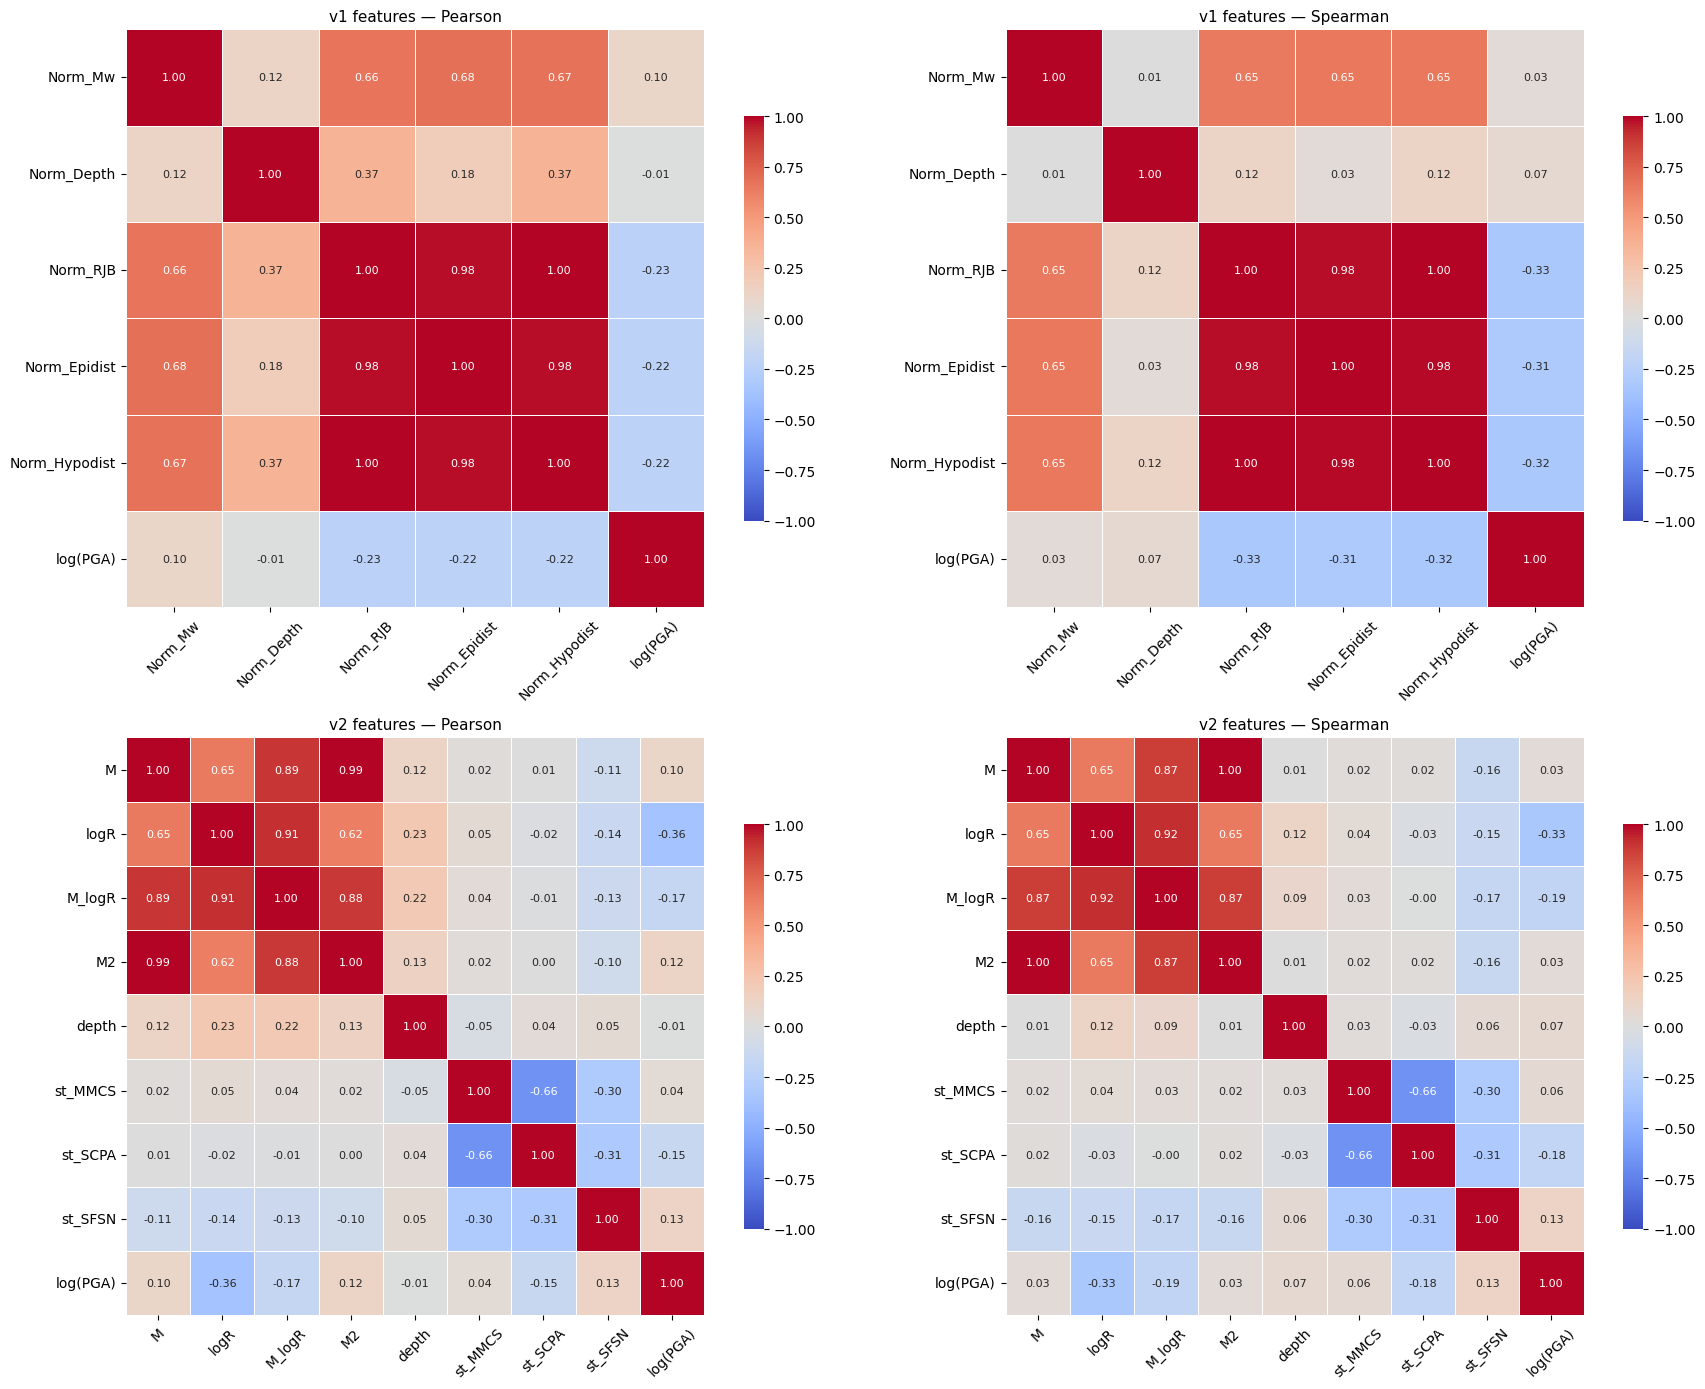


v2 — features ranked by |Spearman| with log(PGA):
logR      -0.326
M_logR    -0.188
st_SCPA   -0.185
st_SFSN    0.126
depth      0.069
st_MMCS    0.062
M          0.031
M2         0.031
Name: log(PGA), dtype: float64


In [8]:
import seaborn as sns

v1_df = pd.DataFrame(X_v1_train, columns=feats).assign(**{'log(PGA)': y_train})
v2_df_train = X_v2_df.iloc[idx_train].reset_index(drop=True).assign(**{'log(PGA)': y_train})

corr_specs = [
    ('v1 features', v1_df, 'pearson'),
    ('v1 features', v1_df, 'spearman'),
    ('v2 features', v2_df_train, 'pearson'),
    ('v2 features', v2_df_train, 'spearman'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, (label, frame, method) in zip(axes.flat, corr_specs):
    corr = frame.corr(method=method)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, cbar_kws={'shrink': 0.7}, ax=ax,
                annot_kws={'size': 8})
    ax.set_title(f'{label} — {method.capitalize()}', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout(); plt.show()

print('\nv2 — features ranked by |Spearman| with log(PGA):')
target_corr = v2_df_train.corr(method='spearman')['log(PGA)'].drop('log(PGA)')
print(target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).round(3))

## 5. XGBoost with default-ish hyperparameters

In [9]:
model_xgb = xgb.XGBRegressor(
    n_estimators=1000, max_depth=4, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0, min_child_weight=3,
    early_stopping_rounds=30, eval_metric='rmse',
    random_state=SEED, n_jobs=-1,
)
model_xgb.fit(X_v2_train_raw_os, y_train_os, eval_set=[(X_v2_val_raw, y_val)], verbose=False)
yp_xgb_log = model_xgb.predict(X_v2_val_raw)
print(f'XGBoost — best_iteration={model_xgb.best_iteration}')

XGBoost — best_iteration=152


## 6. Hyperparameter tuning (Optuna + 5-fold CV)

Tune XGBoost with Bayesian optimization. The procedure:

1. **Search space.** 8 hyperparameters (`max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `reg_lambda`, `reg_alpha`, `min_child_weight`, `gamma`). `n_estimators` is fixed at 2000 with `early_stopping_rounds=30`, so each trial picks the right tree count automatically.
2. **Objective.** Mean RMSE (log space) over 5-fold CV on the **original (non-oversampled) 50% train half**. The val half is *never* touched during tuning, and we deliberately exclude oversampled rows from CV — running 5-fold splits over bootstrap-duplicated rows would leak the same source row into both fold-train and fold-val and inflate the CV score.
3. **Inside each fold.** A small slice of fold-train is held out for early stopping, so each trial gets a fair `best_iteration`.
4. **Sampler.** TPE (Tree-structured Parzen Estimator) — Bayesian, learns from past trials.
5. **Final fit.** Best params retrained on the **oversampled** train half with early stopping on the val half, then evaluated on val.

Why CV instead of a single val split for tuning: with only ~547 train rows, a single-fold tune would be noisy and easy to overfit hyperparameters to. 5-fold CV averages over 5 different val rotations and is much more stable.

In [10]:
N_TRIALS = 50  # ~4 min on CPU; bump to 100+ for a more thorough search

# Tune on the ORIGINAL (non-oversampled) 50% train. Running CV after bootstrap+jitter
# would leak rows between fold-train and fold-val (same source row, different jitter)
# and the objective would be inflated. Final retrain (next cell) uses the oversampled set.
def xgb_objective(trial):
    params = {
        'n_estimators': 2000,
        'max_depth':         trial.suggest_int('max_depth', 2, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 1e-3, 5.0, log=True),
        'early_stopping_rounds': 30,
        'eval_metric': 'rmse',
        'random_state': SEED, 'n_jobs': -1, 'verbosity': 0,
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    rmses = []
    for fi, (i_tr, i_va) in enumerate(kf.split(X_v2_train_raw)):
        # Carve out a small early-stopping slice from fold-train
        Xtr, Xes, ytr, yes = train_test_split(
            X_v2_train_raw[i_tr], y_train[i_tr],
            test_size=0.15, random_state=SEED + fi,
        )
        m = xgb.XGBRegressor(**params)
        m.fit(Xtr, ytr, eval_set=[(Xes, yes)], verbose=False)
        rmses.append(np.sqrt(mean_squared_error(y_train[i_va], m.predict(X_v2_train_raw[i_va]))))
    return float(np.mean(rmses))

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nBest CV RMSE_log: {study.best_value:.4f}')
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k:18s} = {v}')

Best trial: 35. Best value: 0.695129: 100%|██████████| 50/50 [01:56<00:00,  2.33s/it]


Best CV RMSE_log: 0.6951
Best params:
  max_depth          = 4
  learning_rate      = 0.057739332336488106
  subsample          = 0.7288255693556704
  colsample_bytree   = 0.7276791378378233
  reg_lambda         = 0.3299368823755308
  reg_alpha          = 0.0010515605902381851
  min_child_weight   = 2
  gamma              = 0.005574658028240958


### 6a. Retrain with best params, evaluate on val

In [11]:
best_params = dict(study.best_params)
best_params.update({
    'n_estimators': 2000, 'early_stopping_rounds': 30,
    'eval_metric': 'rmse', 'random_state': SEED, 'n_jobs': -1, 'verbosity': 0,
})

model_xgb_tuned = xgb.XGBRegressor(**best_params)
model_xgb_tuned.fit(X_v2_train_raw_os, y_train_os, eval_set=[(X_v2_val_raw, y_val)], verbose=False)
yp_xgb_tuned_log = model_xgb_tuned.predict(X_v2_val_raw)
print(f'Tuned XGB — best_iteration={model_xgb_tuned.best_iteration}')

Tuned XGB — best_iteration=137


### 6b. Optimization history

Each dot is one trial's CV RMSE. The line tracks the best value found so far. If it has plateaued, more trials probably won't help; if it's still descending, increase `N_TRIALS`.

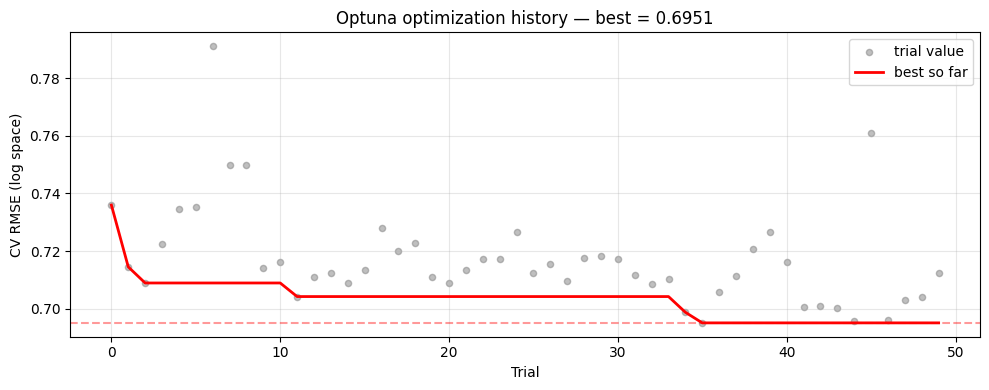

In [12]:
values = np.array([t.value for t in study.trials])
best_so_far = np.minimum.accumulate(values)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(range(len(values)), values, s=20, alpha=0.5, color='gray', label='trial value')
ax.plot(best_so_far, 'r-', linewidth=2, label='best so far')
ax.axhline(study.best_value, color='red', linestyle='--', alpha=0.4)
ax.set_xlabel('Trial')
ax.set_ylabel('CV RMSE (log space)')
ax.set_title(f'Optuna optimization history — best = {study.best_value:.4f}')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 6c. Parameter importance

Computed by Optuna via fANOVA — which hyperparameters explain the most variance in the objective. Tells you which knobs actually matter for this dataset.

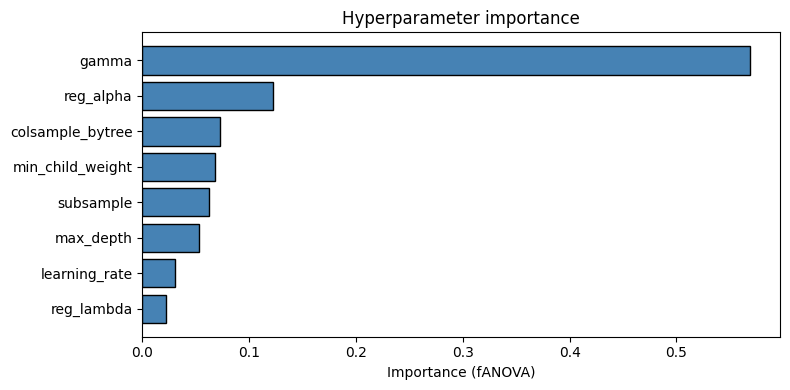

gamma               0.569
reg_alpha           0.123
colsample_bytree    0.072
min_child_weight    0.068
subsample           0.062
max_depth           0.053
learning_rate       0.031
reg_lambda          0.023
dtype: float64


In [13]:
try:
    importances = optuna.importance.get_param_importances(study)
    imp_series = pd.Series(importances).sort_values()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(imp_series.index, imp_series.values, color='steelblue', edgecolor='k')
    ax.set_xlabel('Importance (fANOVA)')
    ax.set_title('Hyperparameter importance')
    plt.tight_layout(); plt.show()
    print(imp_series.sort_values(ascending=False).round(3))
except Exception as e:
    print(f'Importance computation failed: {e}')

### 6d. Slice plot — objective vs each hyperparameter

For each parameter, plot all trials' values vs. that parameter. Reveals whether the optimum is at a boundary (suggesting we should widen the search range).

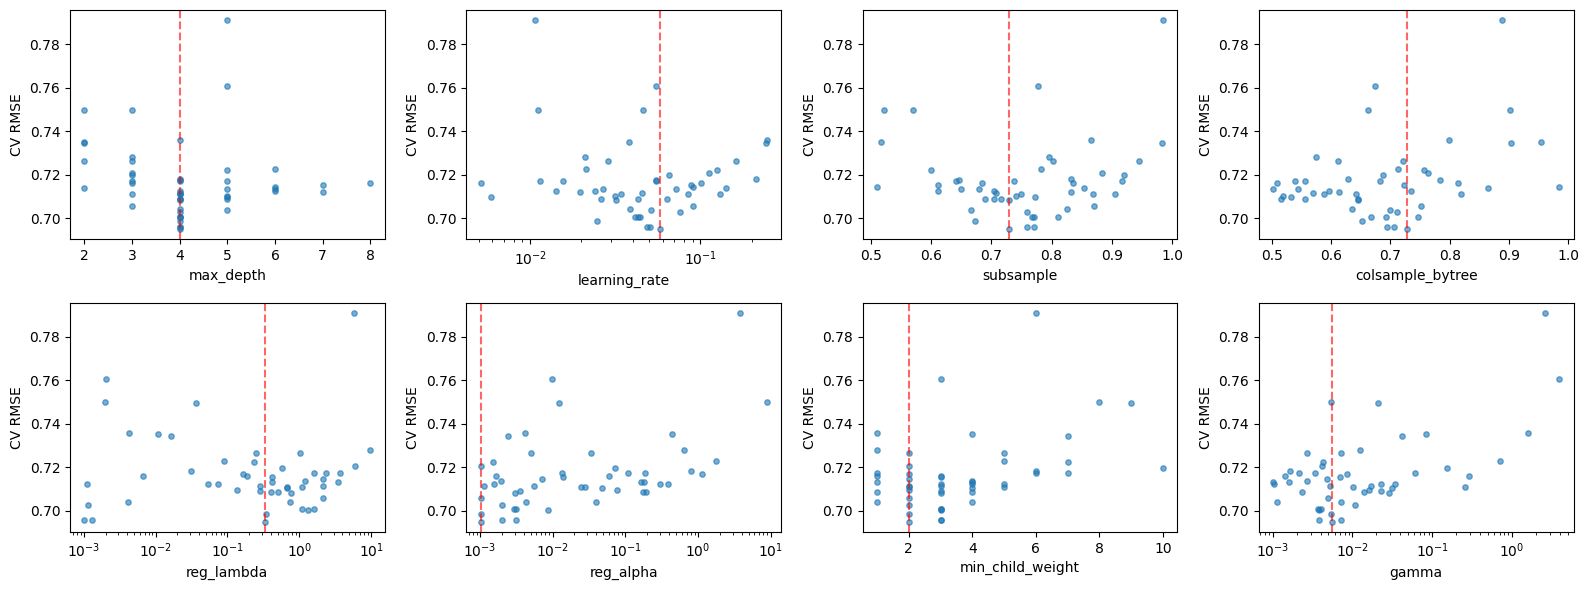

In [14]:
param_names = list(study.best_params.keys())
n = len(param_names)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
for ax, p in zip(axes.flat, param_names):
    xs = [t.params[p] for t in study.trials if p in t.params]
    ys = [t.value for t in study.trials if p in t.params]
    ax.scatter(xs, ys, s=15, alpha=0.6)
    ax.axvline(study.best_params[p], color='red', linestyle='--', alpha=0.6)
    ax.set_xlabel(p); ax.set_ylabel('CV RMSE')
    if p in {'learning_rate', 'reg_lambda', 'reg_alpha', 'gamma'}:
        ax.set_xscale('log')
for ax in axes.flat[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## 7. Compare all four models — point estimates (validation set)

In [15]:
def metric_set(y_true_log, yp_log, y_true_raw):
    yp = np.exp(yp_log)
    return {
        'RMSE_log': float(np.sqrt(mean_squared_error(y_true_log, yp_log))),
        'MAE_log':  float(mean_absolute_error(y_true_log, yp_log)),
        'R2_log':   float(r2_score(y_true_log, yp_log)),
        'RMSE_PGA': float(np.sqrt(mean_squared_error(y_true_raw, yp))),
        'MAE_PGA':  float(mean_absolute_error(y_true_raw, yp)),
        'R2_PGA':   float(r2_score(y_true_raw, yp)),
    }

METRIC_KEYS = ['RMSE_log', 'MAE_log', 'R2_log', 'RMSE_PGA', 'MAE_PGA', 'R2_PGA']
HIGHER_IS_BETTER = {'R2_log', 'R2_PGA'}
MODELS = {
    'v1': yp1_log,
    'v2': yp2_log,
    'xgb': yp_xgb_log,
    'xgb_tuned': yp_xgb_tuned_log,
}
MODEL_COLOR = {'v1': 'tab:blue', 'v2': 'tab:orange', 'xgb': 'tab:green', 'xgb_tuned': 'tab:red'}
model_order = list(MODELS.keys())

points = {name: metric_set(y_val, yp, y_raw_val) for name, yp in MODELS.items()}
results = pd.DataFrame(points).T.round(4)
print(results)

           RMSE_log  MAE_log  R2_log  RMSE_PGA  MAE_PGA  R2_PGA
v1           0.7068   0.5387  0.4850    5.6908   1.8464  0.5311
v2           0.6924   0.5234  0.5058    6.2054   1.8413  0.4424
xgb          0.6873   0.5113  0.5130    6.4236   1.8679  0.4026
xgb_tuned    0.6923   0.5147  0.5059    6.4329   1.8506  0.4008


### 7a. Predicted vs actual (validation set)

One panel per model. Points on the dashed `y=x` line are perfect predictions; points above the line are over-predictions, below are under-predictions. Plotted in log space (where the model is trained) with raw-PGA tick marks on a secondary axis for physical interpretation.

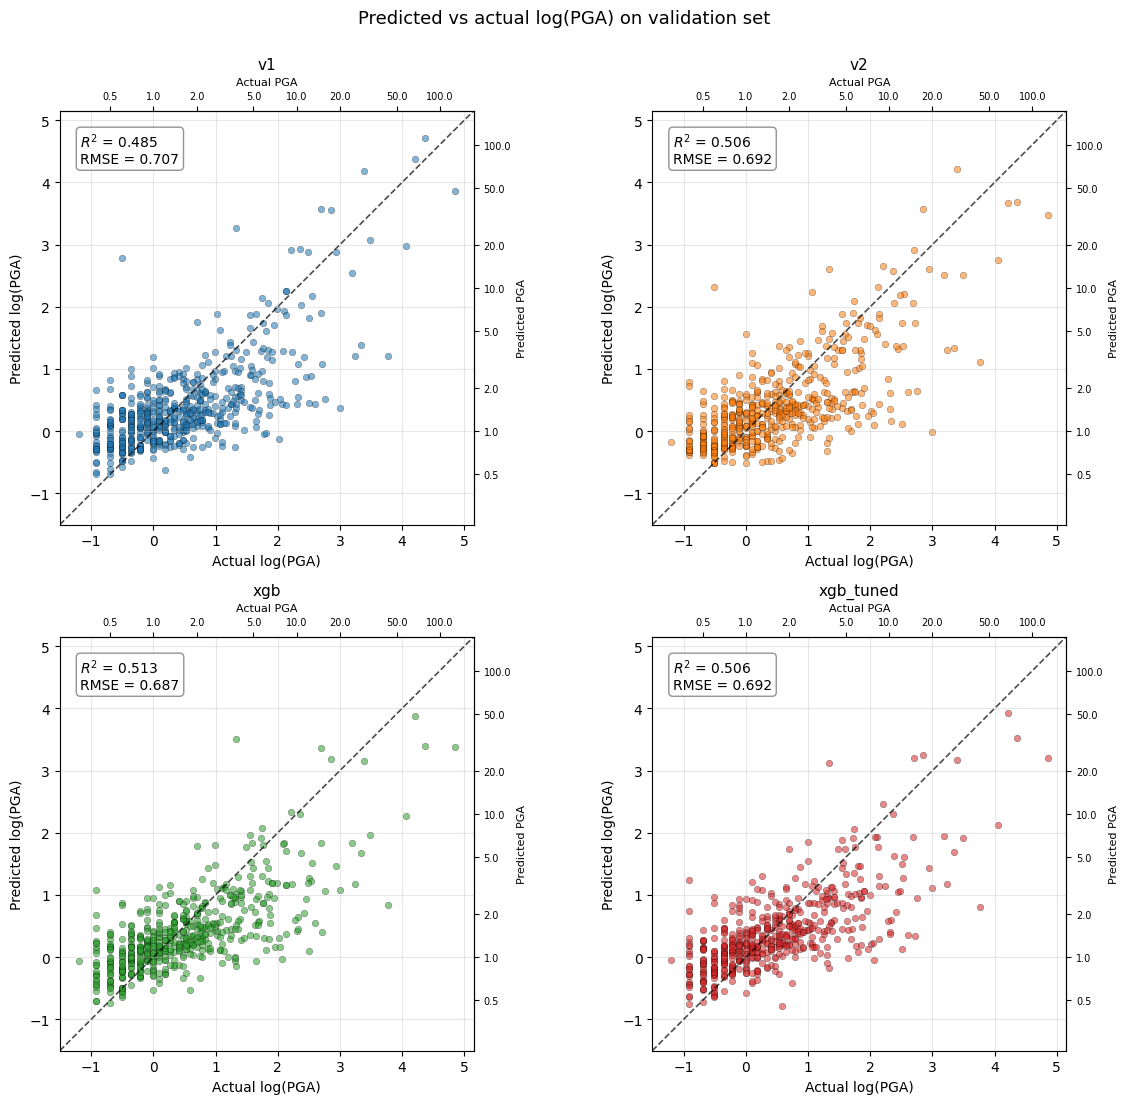

In [16]:
lo = float(min(y_val.min(), *(yp.min() for yp in MODELS.values())))
hi = float(max(y_val.max(), *(yp.max() for yp in MODELS.values())))
pad = 0.05 * (hi - lo)
lims = (lo - pad, hi + pad)

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for ax, name in zip(axes.flat, model_order):
    yp_log = MODELS[name]
    color = MODEL_COLOR[name]
    ax.scatter(y_val, yp_log, s=22, alpha=0.55, color=color, edgecolor='k', linewidth=0.3)
    ax.plot(lims, lims, 'k--', linewidth=1.2, alpha=0.7, label='y = x')
    r2 = r2_score(y_val, yp_log)
    rmse = np.sqrt(mean_squared_error(y_val, yp_log))
    ax.text(0.05, 0.95,
            f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}',
            transform=ax.transAxes, va='top', ha='left',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'))
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
    ax.set_xlabel('Actual log(PGA)'); ax.set_ylabel('Predicted log(PGA)')
    ax.set_title(f'{name}', fontsize=11)
    ax.grid(True, alpha=0.3)

    raw_ticks = np.array([0.5, 1, 2, 5, 10, 20, 50, 100])
    log_ticks = np.log(raw_ticks)
    keep = (log_ticks >= lims[0]) & (log_ticks <= lims[1])
    secx = ax.secondary_xaxis('top', functions=(np.exp, np.log))
    secx.set_xticks(raw_ticks[keep]); secx.set_xlabel('Actual PGA', fontsize=8)
    secx.tick_params(labelsize=7)
    secy = ax.secondary_yaxis('right', functions=(np.exp, np.log))
    secy.set_yticks(raw_ticks[keep]); secy.set_ylabel('Predicted PGA', fontsize=8)
    secy.tick_params(labelsize=7)

plt.suptitle('Predicted vs actual log(PGA) on validation set', y=1.00, fontsize=13)
plt.tight_layout(); plt.show()

## 8. Bootstrap confidence intervals (validation set)

In [17]:
def bootstrap_all(y_eval_log, y_eval_raw, models_yp, n_boot=2000, rng_seed=SEED):
    rng = np.random.default_rng(rng_seed)
    n = len(y_eval_log)
    boot = {name: {k: [] for k in METRIC_KEYS} for name in models_yp}
    for _ in range(n_boot):
        b = rng.integers(0, n, size=n)
        for name, yp in models_yp.items():
            ms = metric_set(y_eval_log[b], yp[b], y_eval_raw[b])
            for k in METRIC_KEYS:
                boot[name][k].append(ms[k])
    return {name: {k: np.array(v) for k, v in d.items()} for name, d in boot.items()}

boot = bootstrap_all(y_val, y_raw_val, MODELS, n_boot=2000)

def ci_table(boot_arrays, point):
    rows = []
    for k in METRIC_KEYS:
        arr = boot_arrays[k]
        rows.append({'metric': k, 'point': point[k],
                     'lo': float(np.percentile(arr, 2.5)),
                     'hi': float(np.percentile(arr, 97.5))})
    return pd.DataFrame(rows).set_index('metric')

ci_tables = {name: ci_table(boot[name], points[name]) for name in MODELS}
for name in MODELS:
    print(f'\n=== {name} (95% CI) ==='); print(ci_tables[name].round(4))


=== v1 (95% CI) ===
           point      lo      hi
metric                          
RMSE_log  0.7068  0.6524  0.7595
MAE_log   0.5387  0.5018  0.5759
R2_log    0.4850  0.3870  0.5640
RMSE_PGA  5.6908  3.5427  7.7716
MAE_PGA   1.8464  1.4366  2.3229
R2_PGA    0.5311  0.2151  0.6652

=== v2 (95% CI) ===
           point      lo      hi
metric                          
RMSE_log  0.6924  0.6374  0.7462
MAE_log   0.5234  0.4855  0.5608
R2_log    0.5058  0.4129  0.5825
RMSE_PGA  6.2054  3.5780  8.6901
MAE_PGA   1.8413  1.4017  2.3471
R2_PGA    0.4424  0.2286  0.5914

=== xgb (95% CI) ===
           point      lo      hi
metric                          
RMSE_log  0.6873  0.6340  0.7390
MAE_log   0.5113  0.4739  0.5514
R2_log    0.5130  0.4410  0.5792
RMSE_PGA  6.4236  3.6810  8.9896
MAE_PGA   1.8679  1.4067  2.3988
R2_PGA    0.4026  0.1799  0.5677

=== xgb_tuned (95% CI) ===
           point      lo      hi
metric                          
RMSE_log  0.6923  0.6393  0.7476
MAE_log   0.5147 

In [18]:
diff_pairs = [('v2', 'v1'), ('xgb', 'v2'), ('xgb_tuned', 'xgb'), ('xgb_tuned', 'v2')]
diff_boot, diff_point, diff_ci = {}, {}, {}
for a, b in diff_pairs:
    label = f'{a} - {b}'
    diff_boot[label] = {k: boot[a][k] - boot[b][k] for k in METRIC_KEYS}
    diff_point[label] = {k: points[a][k] - points[b][k] for k in METRIC_KEYS}
    diff_ci[label] = ci_table(diff_boot[label], diff_point[label])

for label, tbl in diff_ci.items():
    print(f'\n=== {label} (95% CI) ==='); print(tbl.round(4))


=== v2 - v1 (95% CI) ===
           point      lo      hi
metric                          
RMSE_log -0.0145 -0.0394  0.0113
MAE_log  -0.0153 -0.0375  0.0079
R2_log    0.0209 -0.0162  0.0582
RMSE_PGA  0.5146 -0.1895  1.0663
MAE_PGA  -0.0051 -0.1362  0.1239
R2_PGA   -0.0886 -0.1371  0.0612

=== xgb - v2 (95% CI) ===
           point      lo      hi
metric                          
RMSE_log -0.0051 -0.0404  0.0284
MAE_log  -0.0121 -0.0360  0.0118
R2_log    0.0072 -0.0393  0.0608
RMSE_PGA  0.2182 -0.4600  0.7559
MAE_PGA   0.0266 -0.1513  0.1906
R2_PGA   -0.0399 -0.1848  0.1090

=== xgb_tuned - xgb (95% CI) ===
           point      lo      hi
metric                          
RMSE_log  0.0050 -0.0040  0.0134
MAE_log   0.0034 -0.0032  0.0097
R2_log   -0.0071 -0.0195  0.0056
RMSE_PGA  0.0092 -0.3587  0.2558
MAE_PGA  -0.0173 -0.0726  0.0272
R2_PGA   -0.0017 -0.0412  0.0955

=== xgb_tuned - v2 (95% CI) ===
           point      lo      hi
metric                          
RMSE_log -0.0001 -0.03

### 8a. Forest plot — four models, all metrics

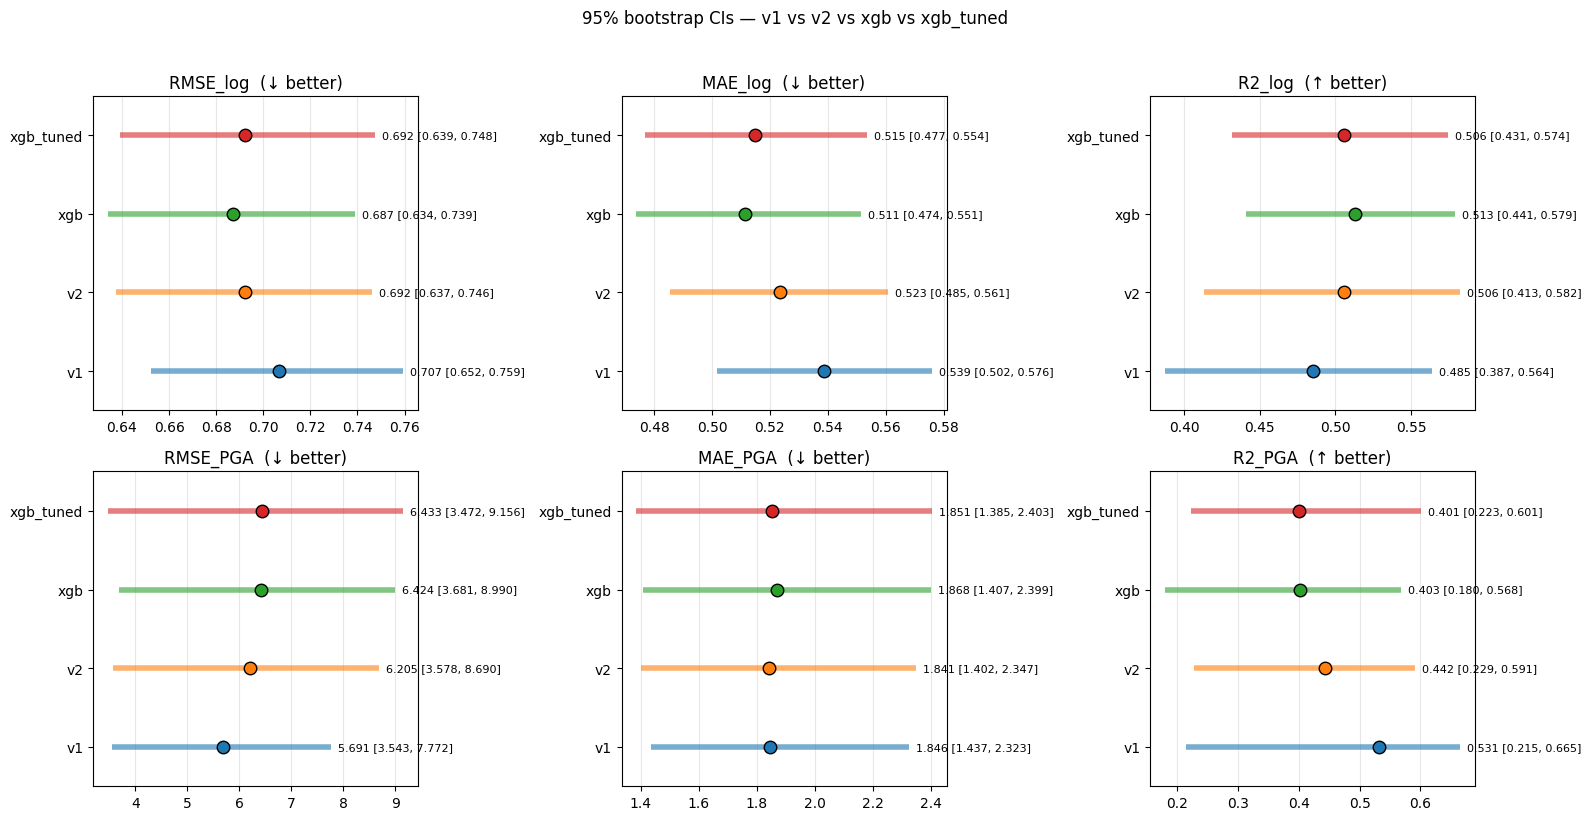

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, k in zip(axes.flat, METRIC_KEYS):
    for i, name in enumerate(model_order):
        row = ci_tables[name].loc[k]
        ax.hlines(i, row['lo'], row['hi'], color=MODEL_COLOR[name], linewidth=4, alpha=0.6)
        ax.plot(row['point'], i, 'o', color=MODEL_COLOR[name], markersize=9, markeredgecolor='k')
        ax.text(row['hi'], i, f"  {row['point']:.3f} [{row['lo']:.3f}, {row['hi']:.3f}]",
                va='center', fontsize=8)
    ax.set_yticks(range(len(model_order))); ax.set_yticklabels(model_order)
    ax.set_ylim(-0.5, len(model_order) - 0.5)
    direction = '↑ better' if k in HIGHER_IS_BETTER else '↓ better'
    ax.set_title(f'{k}  ({direction})')
    ax.grid(True, axis='x', alpha=0.3)
plt.suptitle('95% bootstrap CIs — v1 vs v2 vs xgb vs xgb_tuned', y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

### 8b. Bootstrap distributions

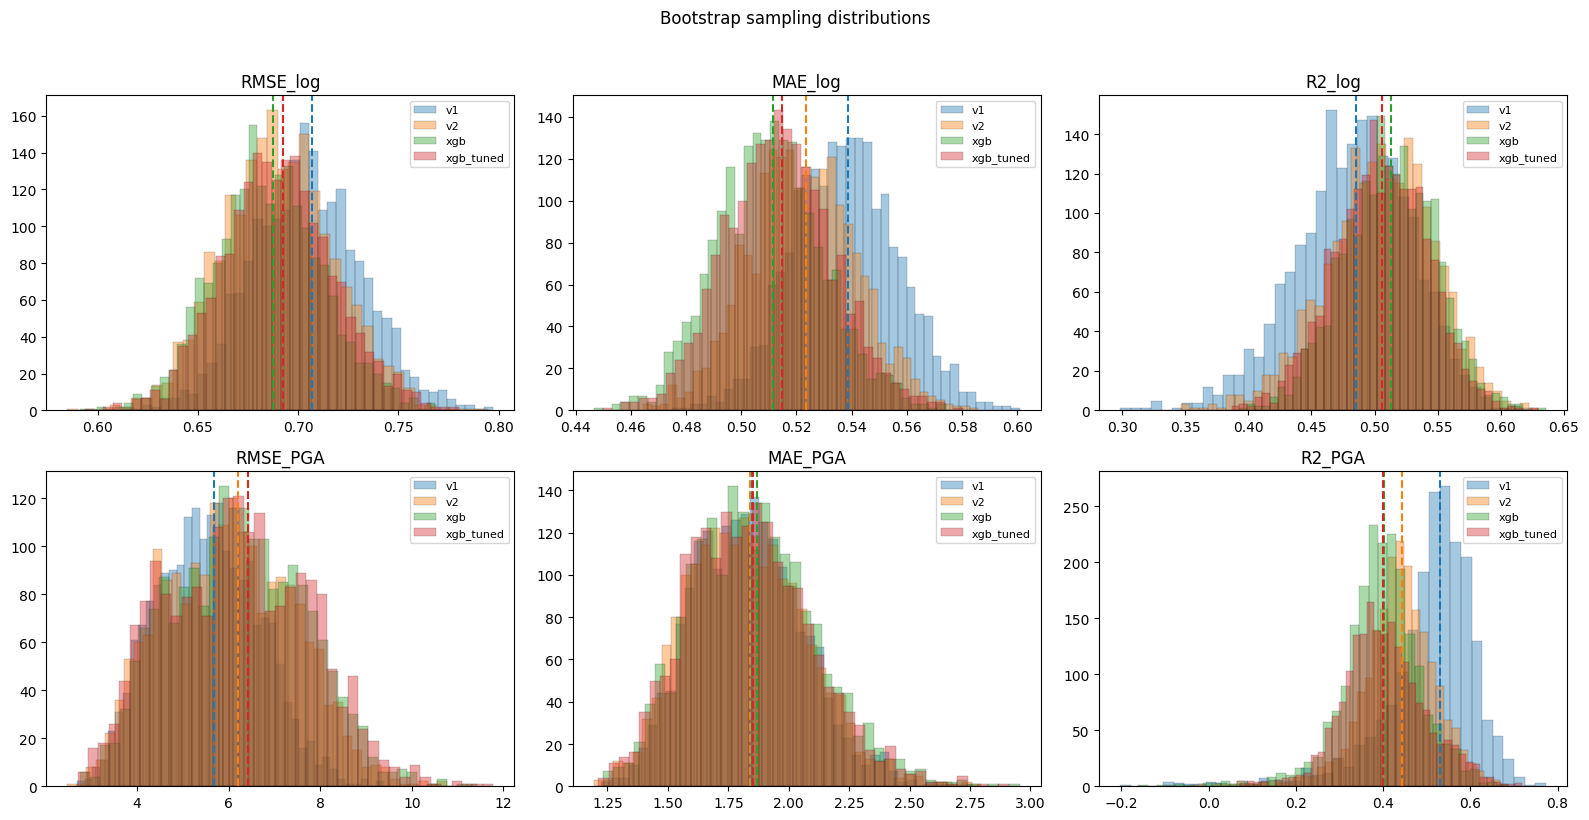

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, k in zip(axes.flat, METRIC_KEYS):
    for name in model_order:
        ax.hist(boot[name][k], bins=40, alpha=0.4, color=MODEL_COLOR[name], label=name, edgecolor='k', linewidth=0.3)
        ax.axvline(points[name][k], color=MODEL_COLOR[name], linestyle='--', linewidth=1.5)
    ax.set_title(k); ax.legend(loc='best', fontsize=8)
plt.suptitle('Bootstrap sampling distributions', y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

### 8c. Paired-difference distributions

Key pairs: `v2 − v1` (does feature engineering help?), `xgb − v2` (does XGBoost beat the MLP?), `xgb_tuned − xgb` (does tuning help?), `xgb_tuned − v2` (best model vs improved MLP).

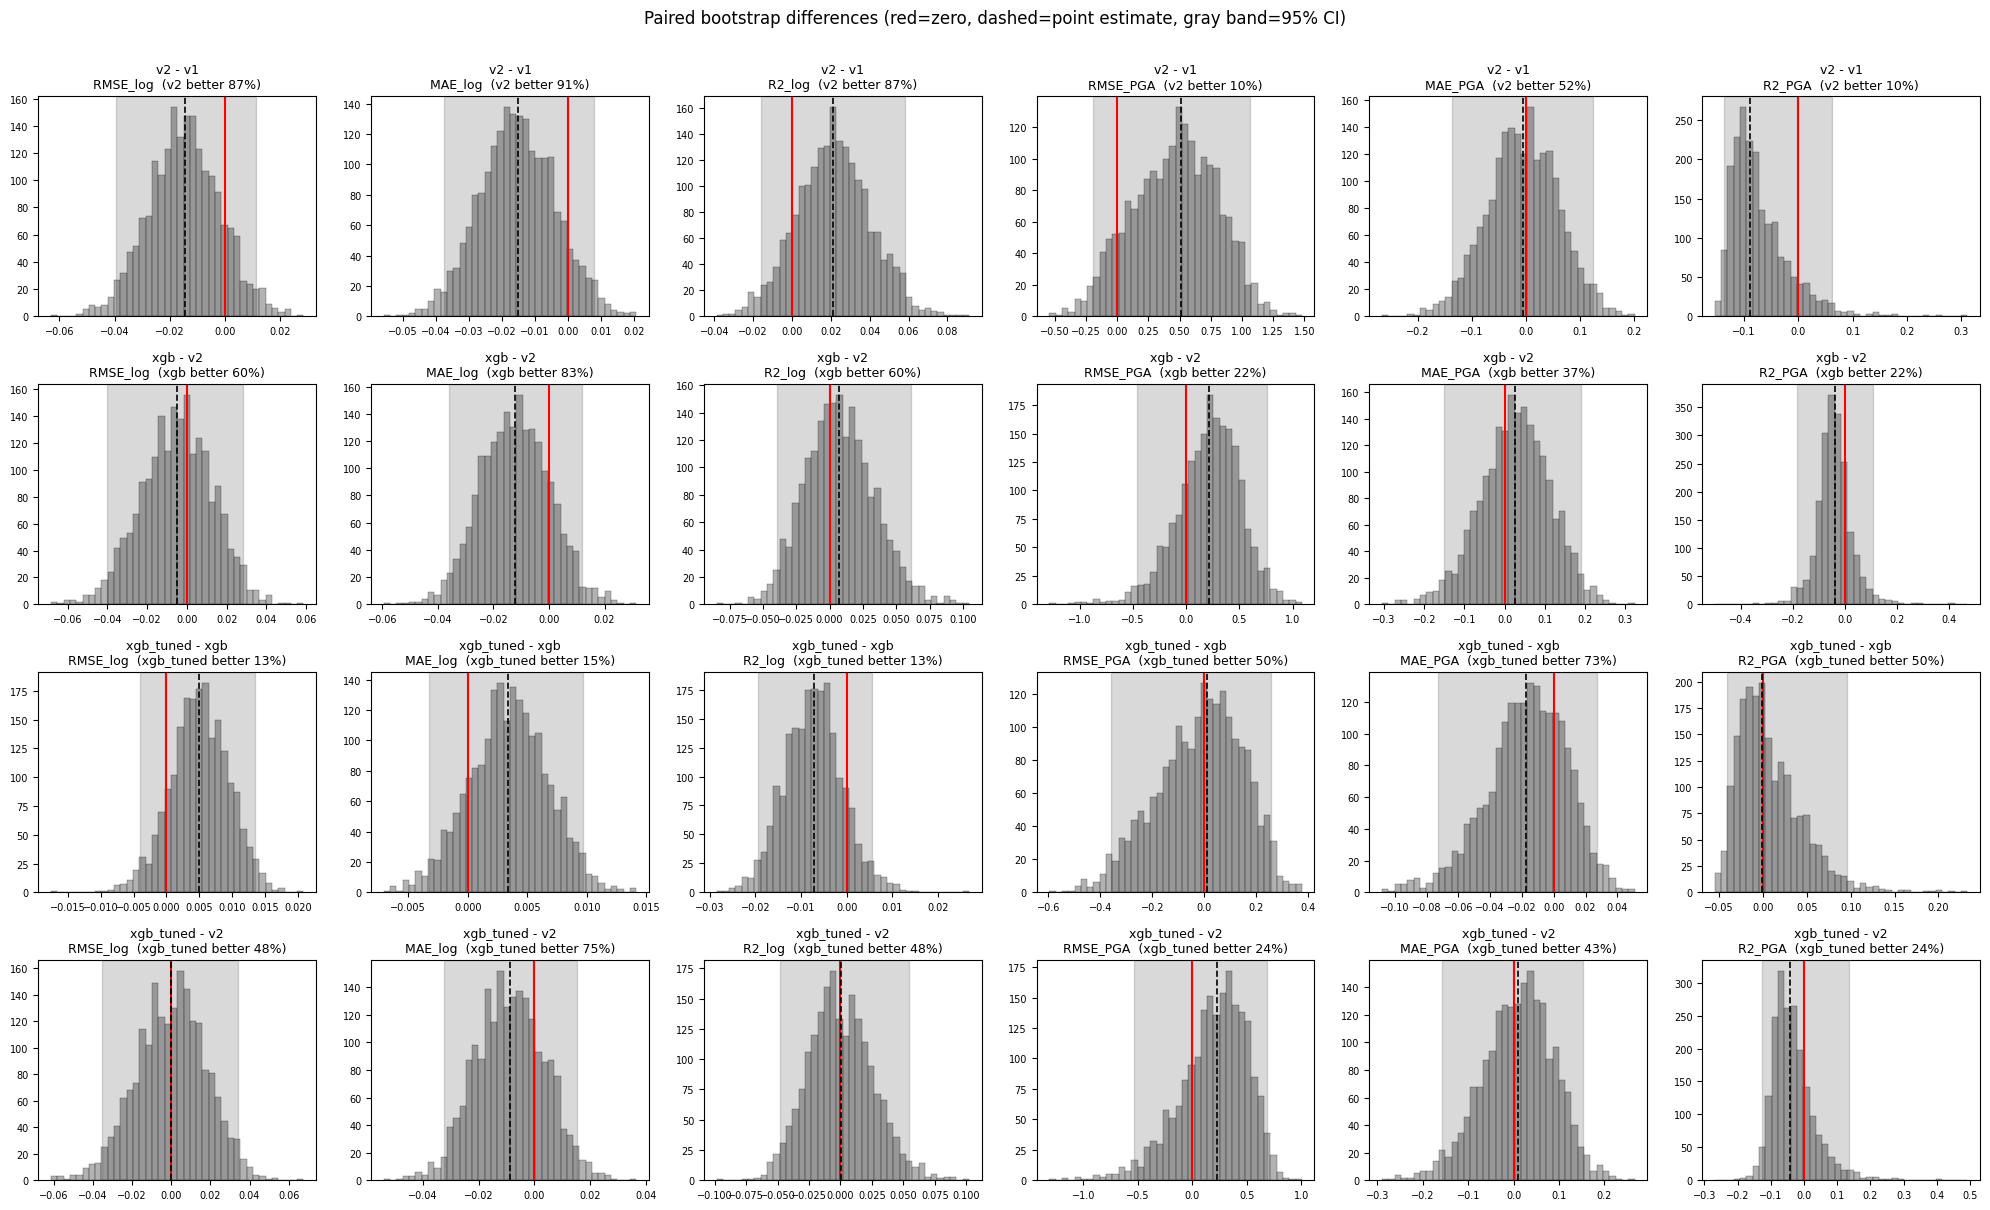

In [21]:
n_pairs = len(diff_pairs)
fig, axes = plt.subplots(n_pairs, 6, figsize=(20, 3 * n_pairs))
for row, (a, b) in enumerate(diff_pairs):
    label = f'{a} - {b}'
    for col, k in enumerate(METRIC_KEYS):
        ax = axes[row, col]
        diffs = diff_boot[label][k]
        lo = diff_ci[label].loc[k, 'lo']; hi = diff_ci[label].loc[k, 'hi']
        favors_a = (diffs > 0).mean() if k in HIGHER_IS_BETTER else (diffs < 0).mean()
        ci_excludes_zero = (lo > 0) or (hi < 0)
        color = 'tab:green' if ci_excludes_zero else 'tab:gray'
        ax.hist(diffs, bins=40, color=color, alpha=0.6, edgecolor='k', linewidth=0.3)
        ax.axvline(0, color='red', linestyle='-', linewidth=1.5)
        ax.axvline(diff_point[label][k], color='black', linestyle='--', linewidth=1.2)
        ax.axvspan(lo, hi, alpha=0.15, color='black')
        ax.set_title(f'{label}\n{k}  ({a} better {favors_a*100:.0f}%)', fontsize=9)
        ax.tick_params(labelsize=7)
plt.suptitle('Paired bootstrap differences (red=zero, dashed=point estimate, gray band=95% CI)',
             y=1.005, fontsize=12)
plt.tight_layout(); plt.show()

## 9. Save best models + tuning artifact

In [22]:
import joblib, json
os.makedirs('../models', exist_ok=True)
model_v2.save('../models/pga_perceptron_v2.keras')
joblib.dump(scaler, '../models/pga_perceptron_v2_scaler.pkl')
joblib.dump(list(X_v2_df.columns), '../models/pga_v2_features.pkl')
model_xgb.save_model('../models/pga_xgb.json')
model_xgb_tuned.save_model('../models/pga_xgb_tuned.json')
with open('../models/pga_xgb_tuned_params.json', 'w') as f:
    json.dump({'best_params': study.best_params,
               'best_cv_rmse_log': float(study.best_value),
               'best_iteration': int(model_xgb_tuned.best_iteration)}, f, indent=2)
print('Saved v2 (.keras + scaler), xgb (.json), xgb_tuned (.json + params.json)')

Saved v2 (.keras + scaler), xgb (.json), xgb_tuned (.json + params.json)


## 10. Notes

- **No held-out test set.** The split is 50/50 train/val and all section 7+ metrics are computed on val — the same set early-stopping watches. Reported R²/RMSE will be **mildly optimistic** vs. a truly held-out set. Switch to 40/40/20 if you need honest test numbers.
- **Why CV inside Optuna?** Tuning on a single val set with ~547 rows gives noisy objective values, and the optimizer would overfit hyperparameters to that one split. 5-fold CV stabilizes the signal at 5× cost per trial.
- **Why early stopping inside CV?** With variable `learning_rate` and `max_depth`, the optimal `n_estimators` changes per trial. Letting early stopping pick it gives each trial a fair shot.
- **Why CV runs on non-oversampled rows.** Bootstrap+jitter duplicates source rows; if those duplicates landed in different fold-train/fold-val splits, the CV objective would be inflated by leakage. The final retrain uses the oversampled set.
- **Slice plot caveats.** If the optimum sits at a search-range boundary, widen that range and rerun. Common bounds to watch: very low `learning_rate` (might want lower), very high `max_depth` (might want higher).
- **Marginal gains, big budget.** With ~547 unique train rows and only 8 features, XGBoost defaults are already close to the ceiling. The clearest path forward is more/better features (VS30, fault mechanism, Vs profile), not more tuning or more aggressive oversampling.